# Darcy Truth Plots


## Imports


In [11]:
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import torch


## Configuration


In [12]:
TEST_PATH = Path('Coursework2/Coursework2_Problem_2/Darcy_2D_data_test.mat')

START_INDEX = 0
NUM_SAMPLES_TO_PLOT = 66
SAMPLES_PER_ROW = 3
COLORMAP = 'viridis'
SAVE_FIGURE = False
FIGURE_DPI = 200

OUTPUT_DIR = Path('problem_2_outputs') / 'darcy_truth_plots'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_PATH = OUTPUT_DIR / 'darcy_test_truth_samples.png'


## Define Protocols


In [13]:
class MatRead(object):
    def __init__(self, file_path):
        super(MatRead).__init__()

        self.file_path = file_path
        self.data = h5py.File(self.file_path)

    def get_a(self):
        a_field = np.array(self.data['a_field']).T
        return torch.tensor(a_field, dtype=torch.float32)

    def get_u(self):
        u_field = np.array(self.data['u_field']).T
        return torch.tensor(u_field, dtype=torch.float32)


## Data Processing


In [14]:
data_reader = MatRead(str(TEST_PATH))
a_test = data_reader.get_a()
u_test = data_reader.get_u()

print('a_test:', a_test.shape)
print('u_test:', u_test.shape)

end_index = min(START_INDEX + NUM_SAMPLES_TO_PLOT, u_test.shape[0])
sample_indices = list(range(START_INDEX, end_index))
print('Sample indices:', sample_indices)


a_test: torch.Size([100, 32, 32])
u_test: torch.Size([100, 32, 32])
Sample indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65]


## Plot


/var/folders/9m/5yl447m538l3dw65wfhnx6xh0000gn/T/ipykernel_75432/3164670214.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.97])


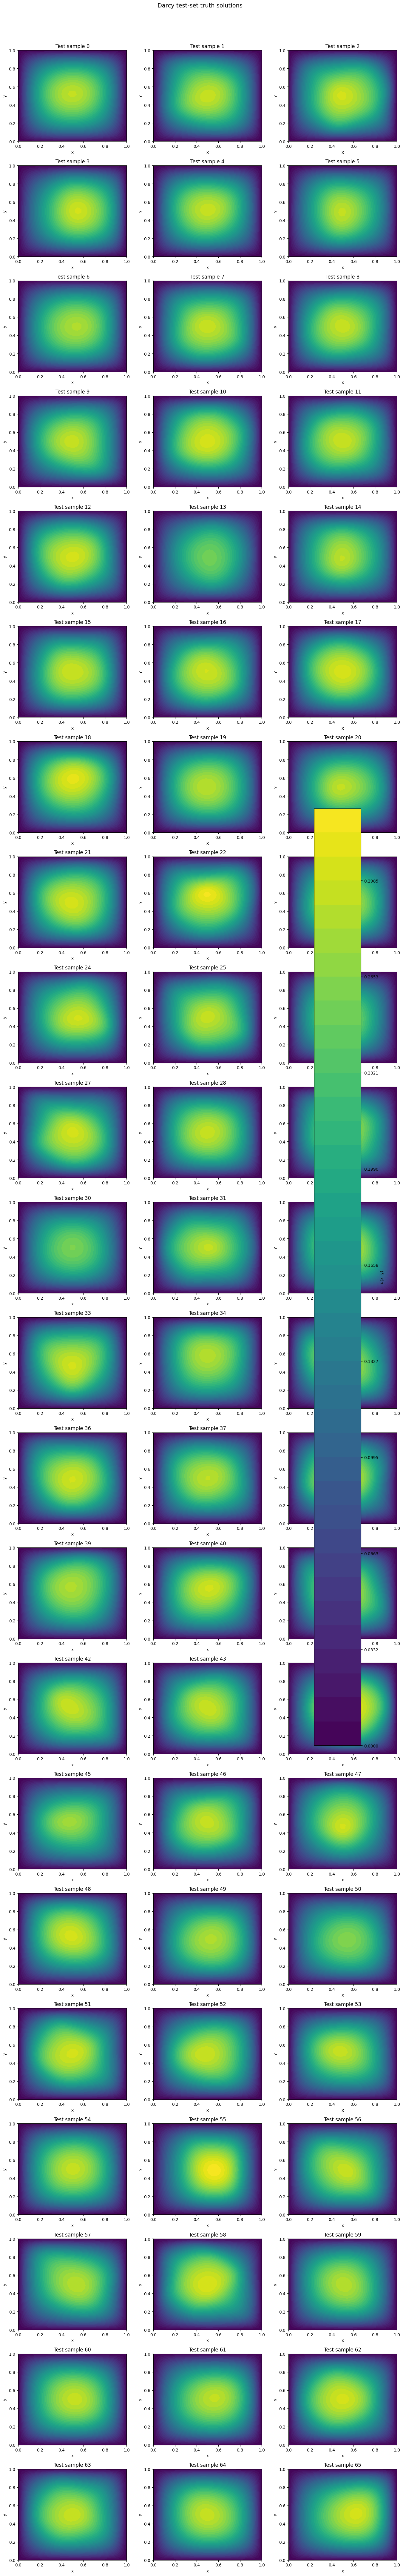

In [15]:
selected_truth = u_test[sample_indices]
field_min = selected_truth.min().item()
field_max = selected_truth.max().item()
levels = np.linspace(field_min, field_max, 40)

num_samples = len(sample_indices)
num_cols = SAMPLES_PER_ROW
num_rows = int(np.ceil(num_samples / num_cols))

fig, axes = plt.subplots(num_rows, num_cols, figsize=(4.5 * num_cols, 4.0 * num_rows))
axes = np.atleast_1d(axes).reshape(num_rows, num_cols)

grid = np.linspace(0, 1, u_test.shape[1])
X, Y = np.meshgrid(grid, grid, indexing='ij')

for ax in axes.flat:
    ax.axis('off')

for ax, sample_index in zip(axes.flat, sample_indices):
    truth = u_test[sample_index].numpy()
    contour = ax.contourf(X, Y, truth, levels=levels, cmap=COLORMAP)
    ax.set_title(f'Test sample {sample_index}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.axis('on')

fig.colorbar(contour, ax=axes.ravel().tolist(), shrink=0.92, label='u(x, y)')
fig.suptitle('Darcy test-set truth solutions', fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.97])

if SAVE_FIGURE:
    fig.savefig(FIGURE_PATH, dpi=FIGURE_DPI, bbox_inches='tight')

plt.show()
